# RAShR from geometry to code
*Repeated Angular Shorth Regression* — Dharavath & Srivastava.  
This notebook builds the estimator **one geometric object at a time**:

`points → chords → directions → projective angles → angular shorth → local directions → repeated shorth → slope → intercept`

Every cell is paired with the paper equation it implements.

In [1]:
# --- setup (run once) -------------------------------------------------------
# %pip install numpy scipy matplotlib pandas   # uncomment if needed
import sys, os
sys.path.insert(0, os.path.abspath(".."))      # so that rashr_core.py (project root) is importable
import numpy as np, matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
SEED = 3                                         # deterministic everywhere

## 0. The data: a compact high-leverage cluster (paper Fig. 1 setting)
62 points follow $y=1+2x+e$, 38 sit in a compact cluster centred at $(15,-10)$ (spread 0.3).

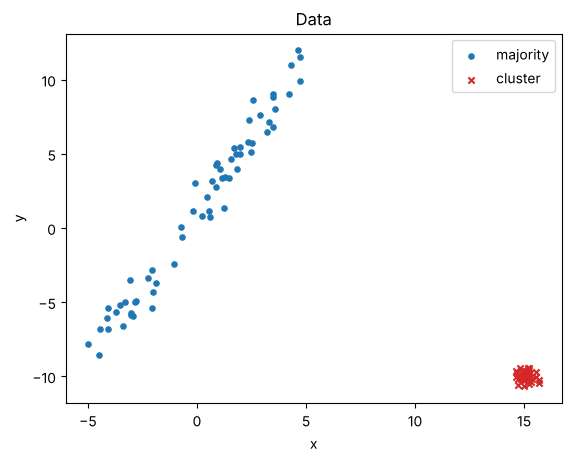

In [2]:
from rashr_core import simulate
rng = np.random.default_rng(SEED)
x, y, bad = simulate(100, 0.38, "compact", rng)
plt.scatter(x[~bad], y[~bad], s=14, label="majority"); plt.scatter(x[bad], y[bad], marker="x", c="C3", s=20, label="cluster")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Data"); plt.show()

## 1. Robust standardization — Eq. (2)
Angles depend on units, so both axes are centred at the median and scaled by $s=1.4826\,\mathrm{MAD}$ (standard deviation if MAD = 0).

In [3]:
def robust_scale(z):
    s = 1.4826 * np.median(np.abs(z - np.median(z)))
    return s if s > 0 else np.std(z)

mx, my, sx, sy = np.median(x), np.median(y), robust_scale(x), robust_scale(y)
u, v = (x - mx) / sx, (y - my) / sy
print(f"s_x = {sx:.3f}, s_y = {sy:.3f}")

s_x = 8.553, s_y = 7.188


## 2. Chord directions — Eq. (3)
For two points the chord direction is $\phi_{ij}=\operatorname{atan2}(v_j-v_i,\,u_j-u_i)\bmod\pi$.  
`atan2` works with the *vector*, so a nearly vertical chord (tiny $u_j-u_i$) is harmless, unlike the ratio $\Delta v/\Delta u$.

In [4]:
def chord_angle(du, dv):
    return np.mod(np.arctan2(dv, du), np.pi)

i, j = 0, 1
print("direction of chord (0,1):", np.degrees(chord_angle(u[j]-u[i], v[j]-v[i])), "deg")
# all chords at once (n x n), then remove the diagonal -> Phi_i has n-1 entries
n = len(u)
phi = chord_angle(u[None, :] - u[:, None], v[None, :] - v[:, None])
Phi = phi[~np.eye(n, dtype=bool)].reshape(n, n - 1)
print(Phi.shape)

direction of chord (0,1): 165.15161544910995 deg
(100, 99)


## 3. The projective circle — Eq. (4)
A line has no orientation: $20^\circ$ and $200^\circ$ are the *same* line. So directions live on $[0,\pi)$ with 0 and $\pi$ glued, and the distance is
$d_\pi(a,b)=\min(|a-b|,\pi-|a-b|)$.

In [5]:
def d_pi(a, b):
    d = np.abs(a - b); return np.minimum(d, np.pi - d)
print(np.degrees(chord_angle(np.cos(np.radians(20)), np.sin(np.radians(20)))),
      np.degrees(chord_angle(np.cos(np.radians(200)), np.sin(np.radians(200)))))   # both 20
print("d_pi(5°,175°) =", np.degrees(d_pi(np.radians(5), np.radians(175))), "deg  (not 170!)")

20.0 19.99999999999998
d_pi(5°,175°) = 9.99999999999999 deg  (not 170!)


## 4. The angular shorth — Eq. (5)
Classical shorth: *shortest interval containing half the data*. Circular version: sort the angles, append a copy shifted by $\pi$ (so arcs crossing the seam become ordinary intervals), slide a window of $h$ consecutive angles, keep the narrowest (ties → smallest left endpoint), and return its midpoint mod $\pi$.

In [6]:
def angular_shorth(A, h=None):
    a = np.sort(np.mod(A, np.pi)); m = len(a)
    h = int(np.ceil(m / 2)) if h is None else h
    ext = np.concatenate([a, a + np.pi])
    widths = ext[h-1 : h-1+m] - ext[:m]          # one window per left endpoint
    r = int(np.argmin(widths))                    # argmin returns the FIRST minimum -> deterministic tie rule
    return (0.5 * (ext[r] + ext[r+h-1])) % np.pi, widths[r]

demo = np.radians([2, 5, 9, 14, 20, 88, 100, 150, 165, 171, 174, 178])
mid, w = angular_shorth(demo)
print(f"ASh = {np.degrees(mid):.1f}°, width = {np.degrees(w):.0f}°  (window crosses the 0°/180° seam)")
print("naive median angle =", np.degrees(np.median(demo)), "° -- not where the data concentrate")

ASh = 0.0°, width = 18°  (window crosses the 0°/180° seam)
naive median angle = 94.0 ° -- not where the data concentrate


## 5. Local directions — Eqs. (6)–(7)
Each observation is an *anchor*. $\Phi_i=\{\phi_{ij}\}_{j\ne i}$, $\theta_i=\mathrm{ASh}(\Phi_i)$ is the dominant direction anchor $i$ sees; $w_i$ is the width of that shortest half-window (small = strong agreement).

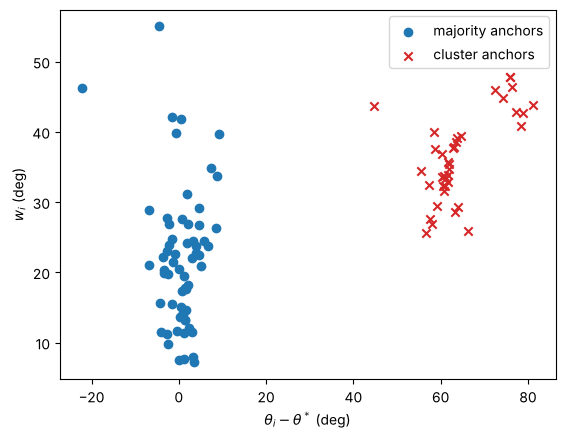

In [7]:
hL = int(np.ceil((n - 1) / 2)); hO = int(np.ceil(n / 2))
theta = np.empty(n); wloc = np.empty(n)
for k in range(n):
    theta[k], wloc[k] = angular_shorth(Phi[k], h=hL)

theta_star = np.arctan(2 * sx / sy)               # the true direction in standardized space
sd = lambda t: np.degrees((t - theta_star + np.pi/2) % np.pi - np.pi/2)
plt.scatter(sd(theta)[~bad], np.degrees(wloc)[~bad], label="majority anchors")
plt.scatter(sd(theta)[bad], np.degrees(wloc)[bad], marker="x", c="C3", label="cluster anchors")
plt.xlabel(r"$\theta_i-\theta^*$ (deg)"); plt.ylabel(r"$w_i$ (deg)"); plt.legend(); plt.show()

## 6. Repeated aggregation — Eq. (8)
Apply the *same* operation to $\theta_1,\dots,\theta_n$ (with $h=\lceil n/2\rceil$). Local aggregation happens inside each anchor; outer aggregation happens across anchors — hence *repeated* angular shorth.

In [8]:
theta_hat, w_out = angular_shorth(theta, h=hO)
print("theta_hat =", np.degrees(theta_hat), "deg, outer width =", np.degrees(w_out), "deg")

theta_hat = 67.45549010546443 deg, outer width = 8.73678350178809 deg


## 7. Back to the original scale — Eqs. (9)–(10)
$\hat\beta=\frac{s_y}{s_x}\tan\hat\theta$ (with $\hat\theta$ represented in $(-\pi/2,\pi/2]$), and $\hat\alpha=\operatorname{med}_i(y_i-\hat\beta x_i)$.

In [9]:
th = theta_hat if theta_hat <= np.pi/2 else theta_hat - np.pi
beta = sy / sx * np.tan(th); alpha = np.median(y - beta * x)
print(f"RAShR: alpha = {alpha:.3f}, beta = {beta:.3f}   (true: 1, 2)")

RAShR: alpha = 0.271, beta = 2.024   (true: 1, 2)


## 8. Validation
The inline implementation must agree with the project module, satisfy the exact-fit property (Prop. 1) and positive-scale equivariance (Prop. 2).

In [10]:
from rashr_core import rashr, ols, lms, mm
a2, b2 = rashr(x, y)
assert np.isclose(b2, beta) and np.isclose(a2, alpha), "inline vs module mismatch"
print("module agrees:", round(b2, 4))

# Prop. 1: exact fit, even under contamination smaller than ceil((n-1)/2)  (Corollary 1)
r = np.random.default_rng(0); xe = r.uniform(-5, 5, 60); ye = 3 + 1.7 * xe
xe[:20], ye[:20] = r.normal(15, .3, 20), r.normal(-10, .3, 20)
ye[20:] = 3 + 1.7 * xe[20:]
print("exact fit with 20/60 contaminated:", rashr(xe, ye))

# Prop. 2: x' = 3+2x, y' = -1+5y  =>  beta' = (5/2) beta
a3, b3 = rashr(3 + 2 * x, -1 + 5 * y)
print("equivariance:", b3, 2.5 * b2)

print({"OLS": ols(x, y)[1], "LMS": lms(x, y)[1], "MM": mm(x, y)[1], "RAShR": b2})

module agrees: 2.0243
exact fit with 20/60 contaminated: (3.0, 1.7)
equivariance: 5.060679697058054 5.060679697058054
{'OLS': -0.5330000019701294, 'LMS': -0.20551709536706478, 'MM': -0.2857097075840694, 'RAShR': 2.024271878823222}


## 9. Where the formulas break (limitations stated in the paper)
* **Not fully affine equivariant**: $y\to y+\gamma x$ changes $s_y$, so it is not a rotation of the standardized data.
* **'All chords near θ*' is too strong** (Remark 1): pairs with almost equal $x$ give almost arbitrary chord directions; RAShR needs only a *concentrated half-sample*.

In [11]:
r = np.random.default_rng(5); xg = r.uniform(-5, 5, 100); yg = 1 + 2 * xg + r.normal(0, 1, 100)
ug, vg = (xg - np.median(xg)) / robust_scale(xg), (yg - np.median(yg)) / robust_scale(yg)
ii, jj = np.triu_indices(100, 1)
ph = chord_angle(ug[jj] - ug[ii], vg[jj] - vg[ii]); ts = np.arctan(2 * robust_scale(xg) / robust_scale(yg))
print("share of majority chords within 22.5° of θ*:", np.mean(np.degrees(d_pi(ph, ts)) < 22.5).round(2))
print("RAShR slope on this noisy sample:", round(rashr(xg, yg)[1], 3))

share of majority chords within 22.5° of θ*: 0.88
RAShR slope on this noisy sample: 1.968
